In [211]:
import io, os, math, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ship_2 import run_ship
from debris_2 import detect_image
from matplotlib.animation import FuncAnimation

In [212]:
plt.rcParams['figure.facecolor'] = 'black'

In [213]:
# ============================================================
# 1️⃣ Input file paths (for local Jupyter or script use)
# ============================================================
#aqua-sentinel-backend\inference-ipynb\Test\Ship\000606_jpg.rf.46705f57e1c8a0429faf58a7893ab486.jpg
# aqua-sentinel-backend\inference-ipynb\images\debris\20170227_203601_0c46_16903-29838-16.jpg
#aqua-sentinel-backend\inference-ipynb\images\debris\20181124_155715_1049_16765-29692-16.jpg
#aqua-sentinel-backend\inference-ipynb\images\ship\000109_jpg.rf.8f6f3b337d10731fc03aa70cb1a0156c.jpg
#aqua-sentinel-backend\inference-ipynb\images\ship\P0001_3000_3800_7200_8000_png.rf.345ea817b061262774162c6305532763.jpg
#aqua-sentinel-backend\inference-ipynb\images\ship\P0004_0_800_8189_8989_png.rf.ebe6588317b2be89aeeedd2b8766b032.jpg
# Example: Update these with your actual file locations
#aqua-sentinel-backend\inference-ipynb\Test\Debris\20161008_153104_0e3a_16821-29831-16.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Debris\20161008_153104_0e3a_16812-29822-16.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Debris\20161008_153104_0e3a_16821-29831-16.jpg
##aqua-sentinel-backend\inference-ipynb\Test\Ship\P0137_80_png.rf.2bd8f2c6a933b847f100e7ac40cb35b3.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\P0135_1800_2600_4200_5000_png.rf.4956e8e03c4d003237b1e6b627b903c2.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Debris\Good-Dynamic-Debris.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\P0133_3600_4400_1800_2600_png.rf.8895a41b84194f903b59d412e16f3386.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Debris\Dynamic-Debris-Single-3.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\000597_jpg.rf.85daff95f1cb4623b0c2fbab8db3548d.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\000606_jpg.rf.46705f57e1c8a0429faf58a7893ab486.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\P0127_3000_3800_8400_9200_png.rf.686cfbf757b4cd9e5fee20dc653049bd.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\P0127_7200_8000_4200_5000_png.rf.74e58323b2a8e27ef7792d9f61546962.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\P0135_1800_2600_4200_5000_png.rf.4956e8e03c4d003237b1e6b627b903c2.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Ship\000010_jpg.rf.a201d8a1c2279e82f5500708b1abda98.jpg
#aqua-sentinel-backend\inference-ipynb\Test\Debris\Still-Better-Dynamic-Debris.jpg
ship_path = r".\Test\Ship\000606_jpg.rf.46705f57e1c8a0429faf58a7893ab486.jpg"
debris_path = r".\Test\Debris\Still-Better-Dynamic-Debris.jpg"
#aqua-sentinel-backend\inference-ipynb\Test\Debris\Existing-Debris-2.jpg
# Validate
import os
if not os.path.exists(ship_path) or not os.path.exists(debris_path):
    raise FileNotFoundError("❌ Check your image paths — one or both files not found!")

print(f"✅ Loaded images successfully:\n  Ship: {ship_path}\n  Debris: {debris_path}")

✅ Loaded images successfully:
  Ship: .\Test\Ship\000606_jpg.rf.46705f57e1c8a0429faf58a7893ab486.jpg
  Debris: .\Test\Debris\Still-Better-Dynamic-Debris.jpg


In [214]:
# ============================================================
# 2️⃣ Run Inference (reuses your ship.py & debris.py logic)
# ============================================================

# Fix model path manually before calling run_ship()
import os
os.environ["SHIP_MODEL_PATH"] = r"D:\4-1\IOMP\AquaSentinel\aqua-sentinel-backend\inference-ipynb\ship_detection.onnx"
os.environ["DEBRIS_MODEL_PATH"] = r"D:\4-1\IOMP\AquaSentinel\aqua-sentinel-backend\inference-ipynb\marine_debris_detector.onnx"

# Now proceed with inference
ship_img_pil = Image.open(ship_path).convert("RGB")
buf = io.BytesIO()
ship_img_pil.save(buf, format="PNG")

# Pass the correct model path explicitly
ship_detected_pil = Image.open(io.BytesIO(
    run_ship(buf.getvalue(), model_path=os.environ["SHIP_MODEL_PATH"])
)).convert("RGB")
ship_np = np.array(ship_detected_pil)[:, :, ::-1]


In [215]:
# --- Debris detection (red boxes) ---
debris_img_pil = Image.open(debris_path).convert("RGB")
debris_detected_pil = detect_image(debris_img_pil, model_path=os.environ["DEBRIS_MODEL_PATH"])
debris_np = np.array(debris_detected_pil)[:, :, ::-1]

In [216]:

# 4️⃣ Keep ORIGINAL colors for overlap (no false-color)
# We’ll overlay the detection outputs directly as they are.
ship_vis   = ship_np          # BGR array of ship detection with BLUE boxes (from ship.py)
debris_vis = debris_np        # BGR array of debris detection with RED boxes (from debris.py)


In [217]:
# # ============================================================
# # 5️⃣ Bounding box & distance computation
# # ============================================================


def detect_color_boxes(img_bgr, color_name, min_area=120):
    """
    Detects rectangle outlines drawn in BLUE (ships) or RED (debris).
    More tolerant HSV ranges + a small morphological close+dilate so
    thin/anti-aliased outlines are detected as solid contours.

    Returns: list[(x1, y1, x2, y2)]
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    if color_name == "blue":
        # WIDER tolerance for blue rectangles drawn by PIL (anti-aliased)
        # Old: H=(90,130)  S,V>=50  -> sometimes misses faded pixels
        lower, upper = (90, 40, 40), (135, 255, 255)
        mask = cv2.inRange(hsv, lower, upper)
    else:
        # Red wraps around 0°, so use two ranges.
        # Lower S,V so light/pale red pixels from anti-aliasing are kept.
        # Old: (0,100,100)-(10,255,255) + (160,100,100)-(180,255,255)
        lower1, upper1 = (0, 70, 70), (12, 255, 255)
        lower2, upper2 = (170, 70, 70), (180, 255, 255)
        mask = cv2.inRange(hsv, lower1, upper1) | cv2.inRange(hsv, lower2, upper2)

    # Solidify thin outlines and bridge gaps caused by anti-aliasing
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    mask = cv2.dilate(mask, k, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h >= min_area:           # filter tiny specks
            boxes.append((x, y, x + w, y + h))

    return boxes



In [218]:
def centers(boxes):
    return [((x1 + x2) // 2, (y1 + y2) // 2) for x1, y1, x2, y2 in boxes]

In [219]:
def compute_pairs(ship_centers, debris_centers):
    out = []
    for i, s in enumerate(ship_centers):
        for j, d in enumerate(debris_centers):
            dist = math.dist(s, d)
            out.append(((i, j), dist))
    return out


In [220]:
h, w, _      = ship_vis.shape
debris_resiz = cv2.resize(debris_np, (w, h))

In [221]:
# detect bounding boxes by color
ship_boxes = detect_color_boxes(ship_np, "blue")
debris_boxes = detect_color_boxes(debris_resiz, "red")
ship_centers = centers(ship_boxes)
debris_centers = centers(debris_boxes)
pairs = compute_pairs(ship_centers, debris_centers)

In [222]:
# ============================================================
# Handle case: no detections found
# ============================================================

if not ship_boxes:
    print("❌ No ship boxes detected — check model output or color threshold.")
if not debris_boxes:
    print("❌ No debris boxes detected — check model output or color threshold.")

if ship_boxes and debris_boxes:
    pairs = compute_pairs(ship_centers, debris_centers)
    closest, min_dist = min(pairs, key=lambda x: x[1])
    threshold = 200
    scale_km = 0.02
    distance_km = min_dist * scale_km
    verdict = "⚠ Possible Culprit Detected" if min_dist < threshold else "✅ No Link Detected"
    print(f"Detected {len(ship_boxes)} ships, {len(debris_boxes)} debris boxes")
    print(f"Closest pair distance: {min_dist:.1f}px (~{distance_km:.2f} km) → {verdict}")
else:
    pairs = []
    min_dist = None
    verdict = "❌ Detection incomplete – check boxes or thresholds."
    print(verdict)


Detected 1 ships, 2 debris boxes
Closest pair distance: 90.6px (~1.81 km) → ⚠ Possible Culprit Detected


In [223]:
# ============================================================
# 6️⃣ Overlay Visualization
# ============================================================

# Transparent blend to place both in the same frame
combined = cv2.addWeighted(ship_vis, 0.6, debris_resiz, 0.6, 0)

In [224]:

# # # draw connections

# 6.1️⃣ Draw ALL pairwise connections in green with numeric distance labels
GREEN = (0, 255, 0)

# (Optional) Re-draw boxes first so the lines appear over them
for (x1, y1, x2, y2) in ship_boxes:
    cv2.rectangle(combined, (x1, y1), (x2, y2), (255, 0, 0), 3)  # blue ship boxes
for (x1, y1, x2, y2) in debris_boxes:
    cv2.rectangle(combined, (x1, y1), (x2, y2), (0, 0, 255), 3)  # red debris boxes

# Now draw lines + labels on top
for (i, j), dist in pairs:
    c1 = ship_centers[i]
    c2 = debris_centers[j]
    cv2.line(combined, c1, c2, GREEN, 2)

    # place distance label at the midpoint of the line
    mid = ((c1[0] + c2[0]) // 2, (c1[1] + c2[1]) // 2)
    cv2.putText(
        combined, f"{dist:.1f}",
        mid, cv2.FONT_HERSHEY_SIMPLEX, 0.55, GREEN, 2, cv2.LINE_AA
    )



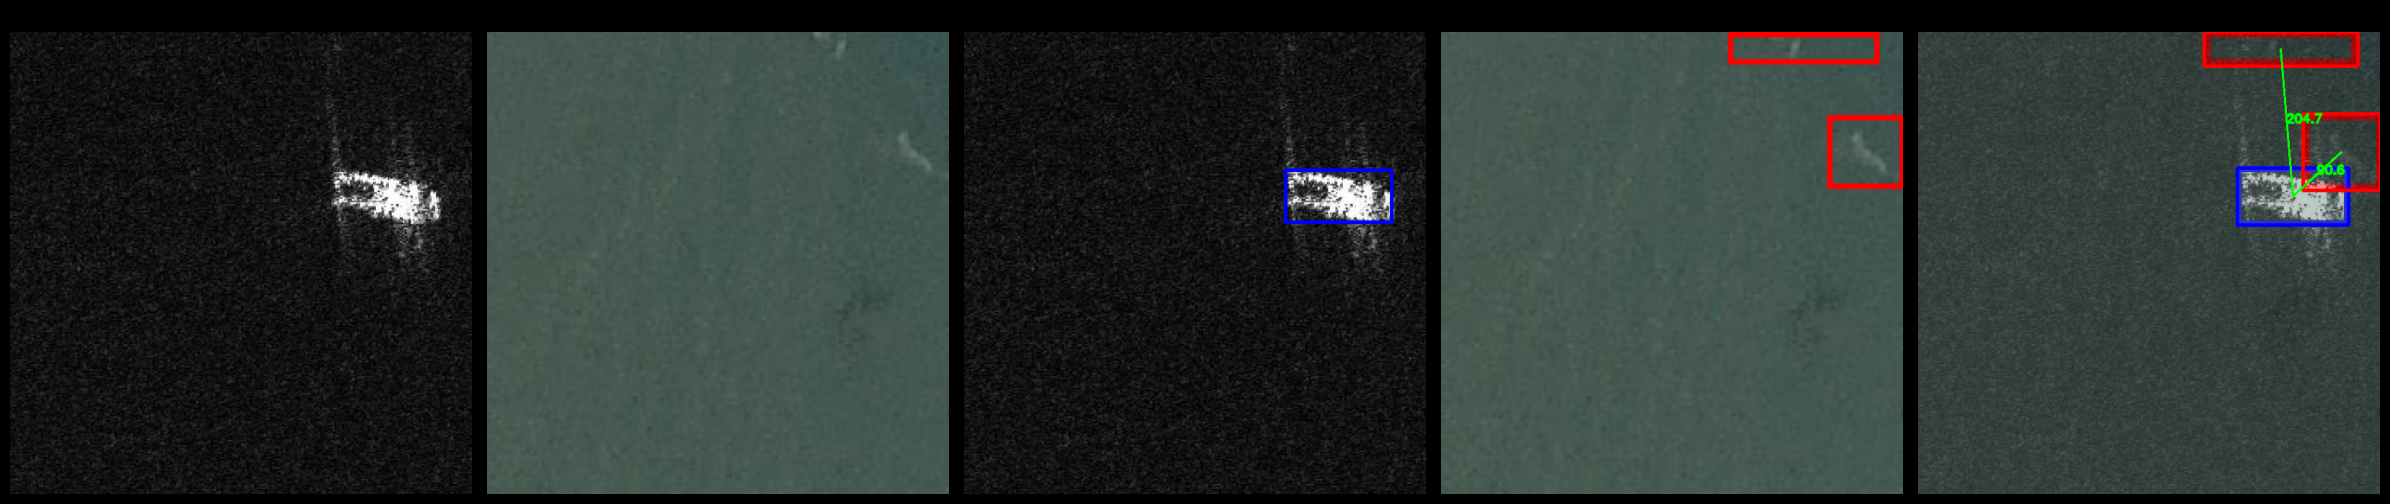

In [225]:
# ============================================================
# 7️⃣ Display all stages
# ============================================================
fig, axs = plt.subplots(1,5,figsize=(24,6))
axs[0].imshow(Image.open(ship_path)); axs[0].set_title("Ship (SAR) – Original")
axs[1].imshow(Image.open(debris_path)); axs[1].set_title("Debris (Optical) – Original")
axs[2].imshow(cv2.cvtColor(ship_np, cv2.COLOR_BGR2RGB)); axs[2].set_title("Ship Detection (Blue Boxes)")
axs[3].imshow(cv2.cvtColor(debris_np, cv2.COLOR_BGR2RGB)); axs[3].set_title("Debris Detection (Red Boxes)")
# combined = cv2.convertScaleAbs(combined, alpha=1.2, beta=10) 
axs[4].imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)); axs[4].set_title("Final Overlap Visualization")
for a in axs: a.axis("off")
plt.tight_layout()
plt.show()